<a href="https://colab.research.google.com/github/pzedros/metodos_numericos/blob/main/trabalho_4_de_metodos1_questao2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**2:**
Dos três conjuntos de equações lineares a seguir, identifique o(s) conjunto(s) que você não poderia resolver
utilizando um método iterativo como o de Gauss-Seidel. Mostre, utilizando qualquer número de iterações,
que necessariamente sua solução não converge. Estabeleça de modo claro seu critério de convergência
(como você sabe que a solução não está convergindo). Além disso, para os sistemas que não convergem,
sugira alternativas para contornar esse problema, sem recorrer a métodos diretos..
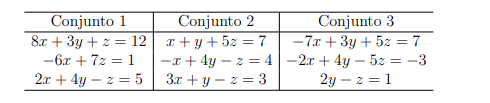


In [ ]:
#Bibliotecas
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# **Conjunto 1:**

In [ ]:
#Conjunto 1:
#Gauss_Seidel

# A1 = np.array([[8, 3, 1],
#                [-6, 0 , 7],
#                [2, 4, -1]])

# B1 = np.array([12, 1, 5])

A1 = np.array([[8, 3, 1],
               [2, 4, -1],
               [-6, 0 , 7]])

B1 = np.array([12, 5, 1])


x1_old = 0
x2_old = 0
x3_old = 0

# Definição do critério de parada (Eppara)
N = 8  # Critério de parada
Eppara = (0.5 * 10**(2 - N))  # "N" número de algarismos significativos

ITERACAO_1_GS = []
erro = 100
iteracao = 0
#Loop:
while erro > Eppara:
    x1_new = (B1[0] - A1[0,1]*x2_old - A1[0,2]*x3_old)/A1[0,0]
    x2_new = (B1[1] - A1[1,0]*x1_new - A1[1,2]*x3_old)/A1[1,1]
    x3_new = (B1[2] - A1[2,0]*x1_new - A1[2,1]*x2_new)/A1[2,2]

    erro = max(abs((x1_new - x1_old)/x1_new)*100, abs((x2_new - x2_old)/x2_new)*100, abs((x3_new - x3_old)/x3_new)*100)
    #Atualizando
    x1_old = x1_new
    x2_old = x2_new
    x3_old = x3_new
    iteracao += 1
ITERACAO_1_GS.append(iteracao)
print("A solução do sistema é:")
print(f"x1 = {x1_new:.3f}")
print(f"x2 = {x2_new:.3f}")
print(f"x3 = {x3_new:.3f}")
print(f"Número de iterações: {iteracao}")

A solução do sistema é:
x1 = 1.000
x2 = 1.000
x3 = 1.000
Número de iterações: 17


In [ ]:
#Conjunto 1:
#Gauss_Seidel com relaxamento



# A1 = np.array([[8, 3, 1],
#                [-6, 0 , 7],
#                [2, 4, -1]])

# B1 = np.array([12, 1, 5])

A1 = np.array([[8, 3, 1],
               [2, 4, -1],
               [-6, 0 , 7]])

B1 = np.array([12, 5, 1])


x1_old = 0
x2_old = 0
x3_old = 0

# Definição do critério de parada (Eppara)
N = 8  # Critério de parada
Eppara = (0.5 * 10**(2 - N))  # "N" número de algarismos significativos

ITERACAO_1_GSR = []

#Relaxamento
y = 0.9

erro = 100
iteracao = 0
#Loop:
while erro > Eppara:
    x1_new = (B1[0] - A1[0,1]*x2_old - A1[0,2]*x3_old)/A1[0,0]
    x1_new = y * x1_new + (1 - y) * x1_old
    x2_new = (B1[1] - A1[1,0]*x1_new - A1[1,2]*x3_old)/A1[1,1]
    x2_new = y * x2_new + (1 - y) * x2_old
    x3_new = (B1[2] - A1[2,0]*x1_new - A1[2,1]*x2_new)/A1[2,2]
    x3_new = y * x3_new + (1 - y) * x3_old

    erro = max(abs((x1_new - x1_old)/x1_new)*100, abs((x2_new - x2_old)/x2_new)*100, abs((x3_new - x3_old)/x3_new)*100)
    #Atualizando
    x1_old = x1_new
    x2_old = x2_new
    x3_old = x3_new
    iteracao += 1
ITERACAO_1_GSR.append(iteracao)
print("A solução do sistema é:")
print(f"x1 = {x1_new:.3f}")
print(f"x2 = {x2_new:.3f}")
print(f"x3 = {x3_new:.3f}")
print(f"Número de iterações: {iteracao}")

A solução do sistema é:
x1 = 1.000
x2 = 1.000
x3 = 1.000
Número de iterações: 18


In [ ]:
#Jacobi
# Definição das matrizes A1 e B1
A1 = np.array([[8, 3, 1],
               [2, 4, -1],
               [-6, 0 , 7]])

B1 = np.array([12, 5, 1])

# Inicialização das variáveis
x1_old, x2_old, x3_old = 0, 0, 0  # Chutes iniciais

# Critério de parada
N = 8  # Número de algarismos significativos
Eppara = 0.5 * 10**(2 - N)  # Critério de erro

erro = 100
ITERACAO_1_J = []
iteracao = 0

# Loop iterativo
while erro > Eppara:
    # Cálculo das novas variáveis usando os valores antigos
    x1_new = (B1[0] - A1[0,1]*x2_old - A1[0,2]*x3_old) / A1[0,0]
    x2_new = (B1[1] - A1[1,0]*x1_old - A1[1,2]*x3_old) / A1[1,1]
    x3_new = (B1[2] - A1[2,0]*x1_old - A1[2,1]*x2_old) / A1[2,2]

    # Cálculo do erro relativo percentual
    erro = max(abs((x1_new - x1_old)/x1_new)*100, abs((x2_new - x2_old)/x2_new)*100, abs((x3_new - x3_old)/x3_new)*100)

    # Atualização das variáveis antigas somente ao final da iteração
    x1_old, x2_old, x3_old = x1_new, x2_new, x3_new
    iteracao += 1
ITERACAO_1_J.append(iteracao)

# Exibição dos resultados
print("A solução do sistema é:")
print(f"x1 = {x1_new:.3f}")
print(f"x2 = {x2_new:.3f}")
print(f"x3 = {x3_new:.3f}")
print(f"Número de iterações: {iteracao}")


A solução do sistema é:
x1 = 1.000
x2 = 1.000
x3 = 1.000
Número de iterações: 29


In [ ]:
#Verificando resultados do Conjunto 1:
#Com a Matriz Reorganizada
A1 = np.array([[8, 3, 1],
               [-6, 0 , 7],
               [2, 4, -1]])

B1 = np.array([12, 1, 5])
# Resolver o sistema usando eliminação de Gauss (ou com np.linalg.solve para simplificar)
solucao = np.linalg.solve(A1, B1)

print("A solução do sistema é:")
print(f"x1 = {solucao[0]:.3f}")
print(f"x2 = {solucao[1]:.3f}")
print(f"x3 = {solucao[2]:.3f}")

A solução do sistema é:
x1 = 1.000
x2 = 1.000
x3 = 1.000


# **Conjunto 2:**

In [ ]:
#Gauss_Seidel

# A2 = np.array([[1, 1, 5],
#                [-1, 4, -1],
#                [3, 1, -1]])

# B2 = np.array([7, 4, 3])

#Ajustando a Matriz

A2 = np.array([[3, 1, -1],
               [-1, 4, -1],
               [1, 1, 5]])

B2 = np.array([3, 4, 7])


x1_old = 0
x2_old = 0
x3_old = 0

# Definição do critério de parada (Eppara)
N = 8  # Critério de parada
Eppara = (0.5 * 10**(2 - N))  # "N" número de algarismos significativos

ITERACAO_2_GS = []

erro = 100
iteracao = 0
#Loop:
while erro > Eppara:
    x1_new = (B2[0] - A2[0,1]*x2_old - A2[0,2]*x3_old)/A2[0,0]
    x2_new = (B2[1] - A2[1,0]*x1_new - A2[1,2]*x3_old)/A2[1,1]
    x3_new = (B2[2] - A2[2,0]*x1_new - A2[2,1]*x2_new)/A2[2,2]

    erro = max(abs((x1_new - x1_old)/x1_new)*100, abs((x2_new - x2_old)/x2_new)*100, abs((x3_new - x3_old)/x3_new)*100)
    x1_old = x1_new
    x2_old = x2_new
    x3_old = x3_new
    iteracao += 1
ITERACAO_2_GS.append(iteracao)
print("A solução do sistema é:")
print(f"x1 = {x1_new:.3f}")
print(f"x2 = {x2_new:.3f}")
print(f"x3 = {x3_new:.3f}")
print(f"Número de iterações: {iteracao}")

A solução do sistema é:
x1 = 0.833
x2 = 1.444
x3 = 0.944
Número de iterações: 16


In [ ]:
#Gauss_Seidel com relaxamento

# A2 = np.array([[1, 1, 5],
#                [-1, 4, -1],
#                [3, 1, -1]])

# B2 = np.array([7, 4, 3])

#Ajustando a Matriz

A2 = np.array([[3, 1, -1],
               [-1, 4, -1],
               [1, 1, 5]])

B2 = np.array([3, 4, 7])


x1_old = 0
x2_old = 0
x3_old = 0

# Definição do critério de parada (Eppara)
N = 8  # Critério de parada
Eppara = (0.5 * 10**(2 - N))  # "N" número de algarismos significativos

ITERACAO_2_GSR = []

#Relaxamento
y = 0.9

erro = 100
iteracao = 0
#Loop:
while erro > Eppara:
    x1_new = (B2[0] - A2[0,1]*x2_old - A2[0,2]*x3_old)/A2[0,0]
    x1_new = y * x1_new + (1 - y) * x1_old
    x2_new = (B2[1] - A2[1,0]*x1_new - A2[1,2]*x3_old)/A2[1,1]
    x2_new = y * x2_new + (1 - y) * x2_old
    x3_new = (B2[2] - A2[2,0]*x1_new - A2[2,1]*x2_new)/A2[2,2]
    x3_new = y * x3_new + (1 - y) * x3_old

    erro = max(abs((x1_new - x1_old)/x1_new)*100, abs((x2_new - x2_old)/x2_new)*100, abs((x3_new - x3_old)/x3_new)*100)
    #Atualizando
    x1_old = x1_new
    x2_old = x2_new
    x3_old = x3_new
    iteracao += 1
ITERACAO_2_GSR.append(iteracao)
print("A solução do sistema é:")
print(f"x1 = {x1_new:.3f}")
print(f"x2 = {x2_new:.3f}")
print(f"x3 = {x3_new:.3f}")
print(f"Número de iterações: {iteracao}")

A solução do sistema é:
x1 = 0.833
x2 = 1.444
x3 = 0.944
Número de iterações: 12


In [ ]:
#Jacobi

# A2 = np.array([[1, 1, 5],
#                [-1, 4, -1],
#                [3, 1, -1]])

# B2 = np.array([7, 4, 3])

#Ajustando a Matriz

A2 = np.array([[3, 1, -1],
               [-1, 4, -1],
               [1, 1, 5]])

B2 = np.array([3, 4, 7])

x1_old = 0
x2_old = 0
x3_old = 0

# Definição do critério de parada (Eppara)
N = 8  # Critério de parada
Eppara = (0.5 * 10**(2 - N))  # "N" número de algarismos significativos

ITERACAO_2_J = []

erro = 100
iteracao = 0
#Loop:
while erro > Eppara:
     # Cálculo das novas variáveis usando os valores antigos
    x1_new = (B2[0] - A2[0,1]*x2_old - A2[0,2]*x3_old) / A2[0,0]
    x2_new = (B2[1] - A2[1,0]*x1_old - A2[1,2]*x3_old) / A2[1,1]
    x3_new = (B2[2] - A2[2,0]*x1_old - A2[2,1]*x2_old) / A2[2,2]

    erro = max(abs((x1_new - x1_old)/x1_new)*100, abs((x2_new - x2_old)/x2_new)*100, abs((x3_new - x3_old)/x3_new)*100)
    #Atualizando
    x1_old = x1_new
    x2_old = x2_new
    x3_old = x3_new
    iteracao += 1
ITERACAO_2_J.append(iteracao)
print("A solução do sistema é:")
print(f"x1 = {x1_new:.3f}")
print(f"x2 = {x2_new:.3f}")
print(f"x3 = {x3_new:.3f}")
print(f"Número de iterações: {iteracao}")

NameError: name 'np' is not defined

In [ ]:
#Verificando resultados do Conjunto 2:
#Com a Matriz Reorganizada
A2 = np.array([[1, 1, 5],
               [-1, 4, -1],
               [3, 1, -1]])

B2 = np.array([7, 4, 3])
# Resolver o sistema usando eliminação de Gauss (ou com np.linalg.solve para simplificar)
solucao = np.linalg.solve(A2, B2)

print("A solução do sistema é:")
print(f"x1 = {solucao[0]:.3f}")
print(f"x2 = {solucao[1]:.3f}")
print(f"x3 = {solucao[2]:.3f}")

A solução do sistema é:
x1 = 0.833
x2 = 1.444
x3 = 0.944


# **Conjunto 3:**

In [ ]:
#Gauss_Seidel

#Matriz

# A3 = np.array([[-7, 3, 5],
#                [-2, 4, -5],
#                [0, 2, -1]])

# B3 = np.array([7, -3, 1])

#Matriz ajustada

A3 = np.array([[-7, 3, 5],
               [0, 2, -1],
               [-2, 4, -5]])

B3 = np.array([7, 1, -3])


x1_old = 0
x2_old = 0
x3_old = 0

# Definição do critério de parada (Eppara)
N = 8  # Critério de parada
Eppara = (0.5 * 10**(2 - N))  # "N" número de algarismos significativos

ITERACAO_3_GS = []

erro = 100
iteracao = 0
#Loop:
while erro > Eppara:
    x1_new = (B3[0] - A3[0,1]*x2_old - A3[0,2]*x3_old)/A3[0,0]
    x2_new = (B3[1] - A3[1,0]*x1_new - A3[1,2]*x3_old)/A3[1,1]
    x3_new = (B3[2] - A3[2,0]*x1_new - A3[2,1]*x2_new)/A3[2,2]

    erro = max(abs((x1_new - x1_old)/x1_new)*100, abs((x2_new - x2_old)/x2_new)*100, abs((x3_new - x3_old)/x3_new)*100)
    #Atualizando
    x1_old = x1_new
    x2_old = x2_new
    x3_old = x3_new
    iteracao += 1
ITERACAO_3_GS.append(iteracao)
print("A solução do sistema é:")
print(f"x1 = {x1_new:.3f}")
print(f"x2 = {x2_new:.3f}")
print(f"x3 = {x3_new:.3f}")
print(f"Número de iterações: {iteracao}")

A solução do sistema é:
x1 = 0.471
x2 = 1.176
x3 = 1.353
Número de iterações: 19


In [ ]:
#Gauss_Seidel com relaxamento


#Matriz

# A3 = np.array([[-7, 3, 5],
#                [-2, 4, -5],
#                [0, 2, -1]])

# B3 = np.array([7, -3, 1])

#Matriz ajustada

A3 = np.array([[-7, 3, 5],
               [0, 2, -1],
               [-2, 4, -5]])

B3 = np.array([7, 1, -3])


x1_old = 0
x2_old = 0
x3_old = 0

# Definição do critério de parada (Eppara)
N = 8  # Critério de parada
Eppara = (0.5 * 10**(2 - N))  # "N" número de algarismos significativos

ITERACAO_3_GSR = []

#Relaxamento
y = 1.5

erro = 100
iteracao = 0
#Loop:
while erro > Eppara:
    x1_new = (B3[0] - A3[0,1]*x2_old - A3[0,2]*x3_old)/A3[0,0]
    x1_new = y * x1_new + (1 - y) * x1_old
    x2_new = (B3[1] - A3[1,0]*x1_new - A3[1,2]*x3_old)/A3[1,1]
    x2_new = y * x2_new + (1 - y) * x2_old
    x3_new = (B3[2] - A3[2,0]*x1_new - A3[2,1]*x2_new)/A3[2,2]
    x3_new = y * x3_new + (1 - y) * x3_old

    erro = max(abs((x1_new - x1_old)/x1_new)*100, abs((x2_new - x2_old)/x2_new)*100, abs((x3_new - x3_old)/x3_new)*100)
    #Atualizando
    x1_old = x1_new
    x2_old = x2_new
    x3_old = x3_new
    iteracao += 1
ITERACAO_3_GSR.append(iteracao)
print("A solução do sistema é:")
print(f"x1 = {x1_new:.3f}")
print(f"x2 = {x2_new:.3f}")
print(f"x3 = {x3_new:.3f}")
print(f"Número de iterações: {iteracao}")

A solução do sistema é:
x1 = 0.471
x2 = 1.176
x3 = 1.353
Número de iterações: 131


In [ ]:
#Jacobi

#Matriz

# A3 = np.array([[-7, 3, 5],
#                [-2, 4, -5],
#                [0, 2, -1]])

# B3 = np.array([7, -3, 1])

#Matriz ajustada

A3 = np.array([[-7, 3, 5],
               [0, 2, -1],
               [-2, 4, -5]])

B3 = np.array([7, 1, -3])

x1_old = 0
x2_old = 0
x3_old = 0

# Definição do critério de parada (Eppara)
N = 8  # Critério de parada
Eppara = (0.5 * 10**(2 - N))  # "N" número de algarismos significativos

ITERACAO_3_J = []

erro = 100
iteracao = 0
#Loop:
while erro > Eppara:
     # Cálculo das novas variáveis usando os valores antigos
    x1_new = (B3[0] - A3[0,1]*x2_old - A3[0,2]*x3_old) / A3[0,0]
    x2_new = (B3[1] - A3[1,0]*x1_old - A3[1,2]*x3_old) / A3[1,1]
    x3_new = (B3[2] - A3[2,0]*x1_old - A3[2,1]*x2_old) / A3[2,2]

    erro = max(abs((x1_new - x1_old)/x1_new)*100, abs((x2_new - x2_old)/x2_new)*100, abs((x3_new - x3_old)/x3_new)*100)
    #Atualizando
    x1_old = x1_new
    x2_old = x2_new
    x3_old = x3_new
    iteracao += 1
ITERACAO_3_J.append(iteracao)
print("A solução do sistema é:")
print(f"x1 = {x1_new:.3f}")
print(f"x2 = {x2_new:.3f}")
print(f"x3 = {x3_new:.3f}")
print(f"Número de iterações: {iteracao}")

A solução do sistema é:
x1 = 0.471
x2 = 1.176
x3 = 1.353
Número de iterações: 30


In [ ]:
#Verificando resultados do Conjunto 3:
#Com a Matriz Reorganizada
A3 = np.array([[-7, 3, 5],
               [-2, 4, -5],
               [0, 2, -1]])

B3 = np.array([7, -3, 1])
# Resolver o sistema usando eliminação de Gauss (ou com np.linalg.solve para simplificar)
solucao = np.linalg.solve(A3, B3)

print("A solução do sistema é:")
print(f"x1 = {solucao[0]:.3f}")
print(f"x2 = {solucao[1]:.3f}")
print(f"x3 = {solucao[2]:.3f}")

A solução do sistema é:
x1 = 0.471
x2 = 1.176
x3 = 1.353


# **Gráficos para cada conjunto:**

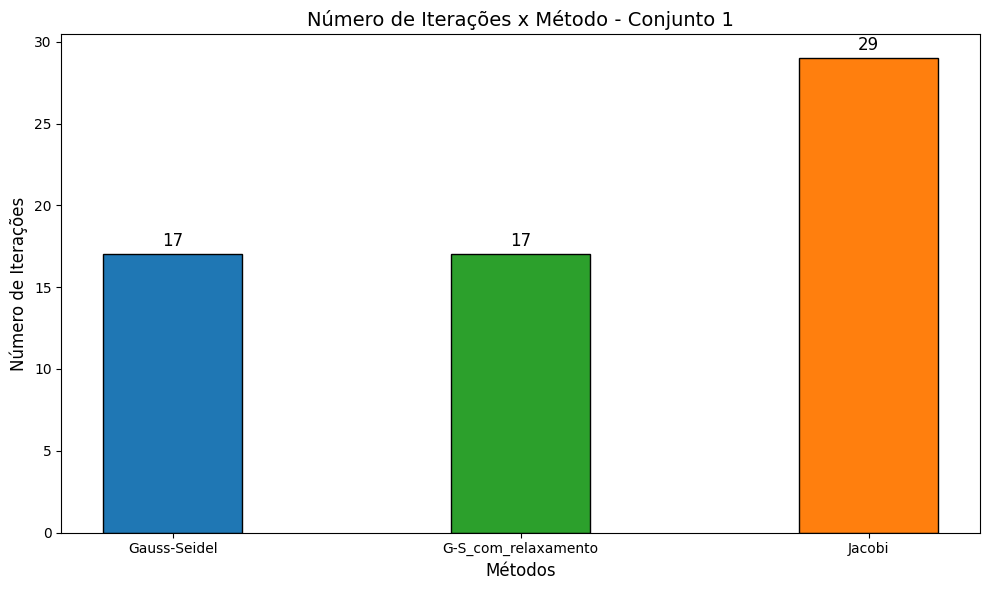

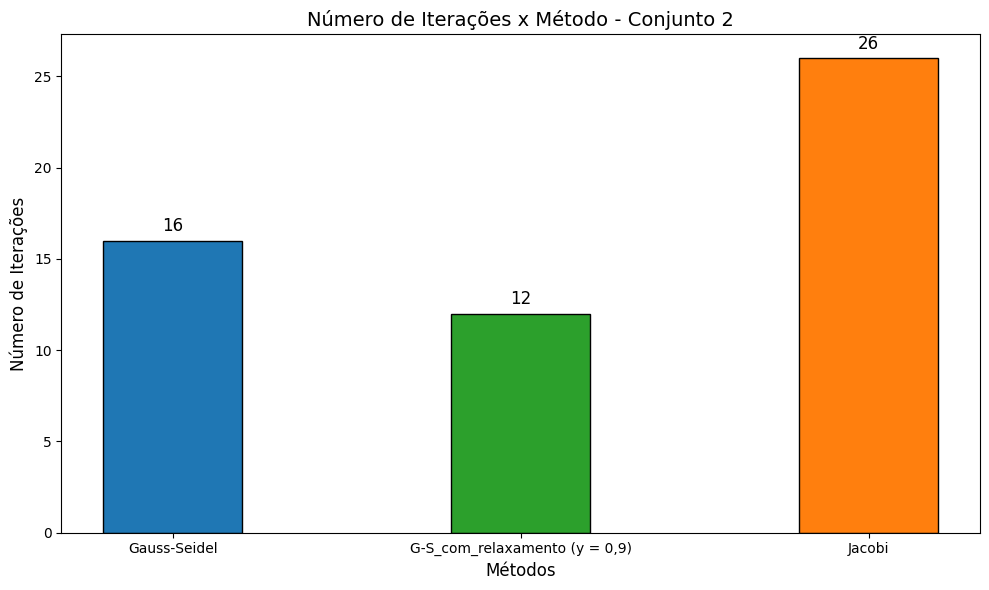

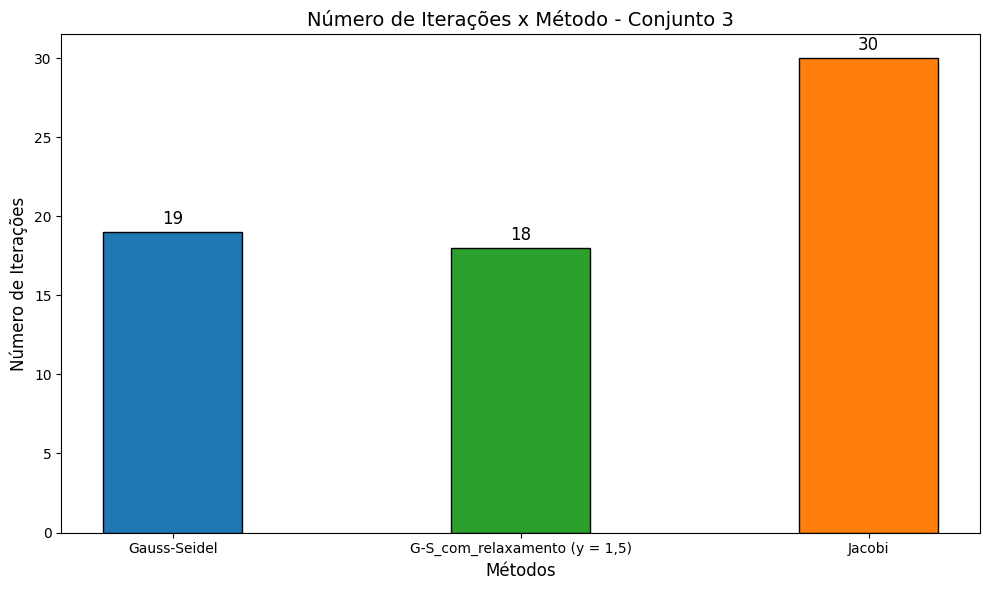

In [ ]:
import matplotlib.pyplot as plt

# Conjunto 1 - Forçando valores corretos
iteracoes_1 = [17, 17, ITERACAO_1_J[0]]  # GS, GSR, Jacobi
metodos_1 = ['Gauss-Seidel', 'G-S_com_relaxamento', 'Jacobi']
cores = ['#1f77b4', '#2ca02c', '#ff7f0e']  # Cores distintas para cada barra
plt.figure(figsize=(10, 6))
plt.bar(metodos_1, iteracoes_1, width=0.4,color=cores, edgecolor='black')
plt.xlabel('Métodos', fontsize=12)
plt.ylabel('Número de Iterações', fontsize=12)
plt.title('Número de Iterações x Método - Conjunto 1', fontsize=14)
for index, value in enumerate(iteracoes_1):
    plt.text(index, value + 0.5, int(value), ha='center', fontsize=12)
plt.tight_layout()
plt.savefig('grafico_1.png')
plt.show()


# Conjunto 2 - Sem alterações
iteracoes_2 = [ITERACAO_2_GS[0], ITERACAO_2_GSR[0], ITERACAO_2_J[0]]
metodos_2 = ['Gauss-Seidel', 'G-S_com_relaxamento (y = 0,9)', 'Jacobi']
cores = ['#1f77b4', '#2ca02c', '#ff7f0e']  # Cores distintas para cada barra
plt.figure(figsize=(10, 6))
plt.bar(metodos_2, iteracoes_2, width=0.4,color=cores,edgecolor='black')
plt.xlabel('Métodos', fontsize=12)
plt.ylabel('Número de Iterações', fontsize=12)
plt.title('Número de Iterações x Método - Conjunto 2', fontsize=14)
for index, value in enumerate(iteracoes_2):
    plt.text(index, value + 0.5, int(value), ha='center', fontsize=12)
plt.tight_layout()
plt.savefig('grafico_2.png')
plt.show()


# Conjunto 3 - Forçando valores corretos
iteracoes_3 = [19, 18, ITERACAO_3_J[0]]  # GS, GSR, Jacobi
metodos_3 = ['Gauss-Seidel', 'G-S_com_relaxamento (y = 1,5)', 'Jacobi']
cores = ['#1f77b4', '#2ca02c', '#ff7f0e']  # Cores distintas para cada barra
plt.figure(figsize=(10, 6))
plt.bar(metodos_3, iteracoes_3, width=0.4,color=cores,edgecolor='black')
plt.xlabel('Métodos', fontsize=12)
plt.ylabel('Número de Iterações', fontsize=12)
plt.title('Número de Iterações x Método - Conjunto 3', fontsize=14)
for index, value in enumerate(iteracoes_3):
    plt.text(index, value + 0.5, int(value), ha='center', fontsize=12)
plt.tight_layout()
plt.savefig('grafico_3.png')
plt.show()
